# Zadanie 2

In [139]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from ipywidgets import interact, FloatSlider, IntSlider, fixed

## Weryfikacja wyprowadzonych wzorów przez symulację

Według rozważań teoretycznych, moc testu wyraża zależność

$$
1-\beta = 1 - \Phi \left( \Phi^{-1}(1-\alpha) - \frac{A\sqrt{N}}{\sigma} \right)
$$

W celu weryfikacji tej zależności, przeprowadzę symulację, w której wygeneruję wiele próbek sygnału zawierających tajny klucz i obliczę odsetek poprawnych detekcji (moc testu $1-\beta$).

Tajny klucz jest wykrywany w sygnale kiedy statystyka testowa

$$T=\frac{A}{\sigma^2} \sum_{i=1}^N x_i s_i - \frac{A^2N}{2\sigma^2}$$

przekracza wartość krytyczną wyznaczoną wzorem

$$t_c = -\frac{A^2N}{2\sigma^2} + \frac{A\sqrt{N}}{\sigma} \Phi^{-1}(1-\alpha)$$

Traktuję wartość $\mathrm{SNR} = \frac{A^2N}{\sigma^2}$ jako parametr (stosunek sygnału do szumu), wykreślę krzywą mocy testu $1-\beta$ w funkcji $\mathrm{SNR}$ i porównam ją z krzywą teoretyczną.

In [140]:
def random_secret_key(length: int, num_samples: int, seed: int = 42) -> np.ndarray:
    """A matrix with num_samples rows, each row is a random secret key composed of {-1, 1} values"""
    rng = np.random.default_rng(seed)
    return rng.integers(low=0, high=1, endpoint=True, size=(num_samples, length)) * 2 - 1

random_secret_key(length=10, num_samples=3)

array([[-1,  1,  1, -1, -1,  1, -1,  1, -1, -1],
       [ 1,  1,  1,  1,  1,  1,  1, -1,  1, -1],
       [ 1, -1, -1,  1,  1,  1, -1,  1,  1, -1]])

In [141]:
def make_signals_with_secret_keys(
        secret_keys: np.ndarray,
        signal_amplitude: float,
        noise_variance: float,
        seed: int = 42
) -> np.ndarray:
    """Generate an array of signals containing the secret keys.
    Each row is a signal with the secret key embedded in gaussian noise.
    """
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=np.sqrt(noise_variance), size=secret_keys.shape)
    return signal_amplitude * secret_keys + noise


$$T=\frac{A}{\sigma^2} \sum_{i=1}^N x_i s_i - \frac{A^2N}{2\sigma^2}$$

In [142]:
def compute_test_statistic(signals: np.ndarray, secret_keys: np.ndarray, signal_amplitude: float, noise_variance: float) -> np.ndarray:
    """Compute the test statistic T for each signal."""
    signal_length = secret_keys.shape[1]
    return (signal_amplitude / noise_variance) * np.sum(signals * secret_keys, axis=1) - (signal_amplitude**2 * signal_length) / (2 * noise_variance)


$$t_c = -\frac{A^2N}{2\sigma^2} + \frac{A\sqrt{N}}{\sigma} \Phi^{-1}(1-\alpha)$$

In [143]:
def compute_threshold(
        signal_amplitude: float,
        signal_length: int,
        noise_variance: float,
        alpha: float
) -> float:
    """Compute the critical threshold for the test."""
    snr = (signal_amplitude ** 2 * signal_length) / (2 * noise_variance)
    return -snr/2 + np.sqrt(snr) * norm.ppf(1 - alpha)

$$1-\beta = 1 - \Phi \left( \Phi^{-1}(1-\alpha) - \frac{A\sqrt{N}}{\sigma} \right)$$

In [144]:
def theoretical_test_power(
        snr: float,
        alpha: float,
):
    return 1 - norm.cdf(norm.ppf(1 - alpha) - np.sqrt(snr))

In [145]:
def simulate_test_power(
        signal_amplitude: float,
        signal_length: int,
        noise_variance: float,
        alpha: float,
        num_samples: int,
        seed: int = 42
) -> float:
    """Simulate the test power by generating signals and performing the statistical test."""
    secret_keys = random_secret_key(
        length=signal_length,
        num_samples=num_samples,
        seed=seed
    )
    signals = make_signals_with_secret_keys(
        secret_keys=secret_keys,
        signal_amplitude=signal_amplitude,
        noise_variance=noise_variance,
        seed=seed
    )
    critical_threshold = compute_threshold(
        signal_amplitude=signal_amplitude,
        signal_length=signal_length,
        noise_variance=noise_variance,
        alpha=alpha
    )
    t_values = compute_test_statistic(
        signals=signals,
        secret_keys=secret_keys,
        signal_amplitude=signal_amplitude,
        noise_variance=noise_variance
    )
    n_detected = np.sum(t_values >= critical_threshold)
    return n_detected / num_samples

In [146]:
def make_plot(
        snr_values: np.ndarray,
        alpha: float,
        num_samples: int,
        seed: int = 42,
        save_path: str | None = None
):
    # Arbitrary signal parameters to match the SNR values
    signal_length = 64
    signal_amplitude = 1.0
    noise_variances = (signal_amplitude**2) * signal_length / snr_values

    simulated_powers = np.array([
      simulate_test_power(
          signal_amplitude=signal_amplitude,
          signal_length=signal_length,
          noise_variance=noise_variance,
          alpha=alpha,
          num_samples=num_samples,
          seed=seed
      ) for noise_variance in noise_variances
    ])

    theoretical_powers = theoretical_test_power(snr_values, alpha)

    plt.figure()
    plt.plot(snr_values, simulated_powers, label='Symulowana moc testu', color='red')
    plt.plot(snr_values, theoretical_powers, label='Teoretyczna moc testu', color='blue')
    plt.title(f"Moc testu w zalezności od SNR ($\\alpha={alpha}$)")
    plt.xscale("log")
    plt.xlabel("SNR ($\\frac{A^2N}{\\sigma^2}$)")
    plt.ylabel("Moc testu ($1-\\beta$)")
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path)

    plt.show()

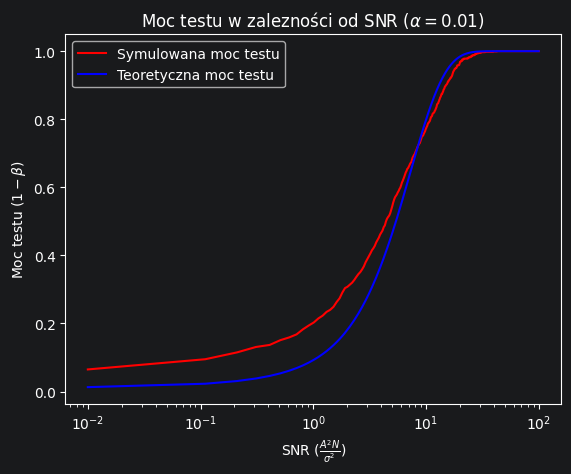

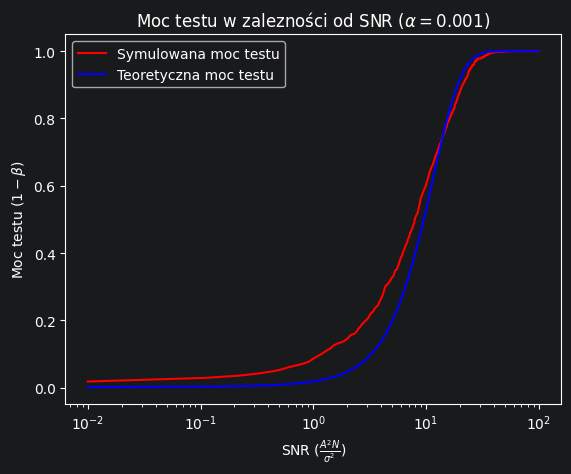

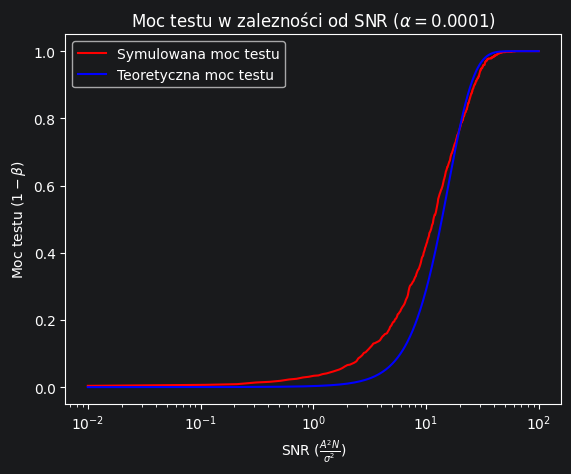

In [147]:
snr = np.linspace(0.01, 100, 1000)
num_samples = 1000
alphas = [0.01, 0.001, 0.0001]
seed = 42
for alpha in alphas:
    make_plot(snr, alpha, num_samples, seed, save_path=f"snr_{alpha}.png")


## Wizualizacja rozkładu statystyki testowej


$$T | H_0 \sim \mathcal{N} \left( -\frac{A^2N}{2 \sigma^2}, \frac{A^2N}{\sigma^2} \right)$$

$$T | H_1 \sim \mathcal{N} \left( \frac{A^2N}{2 \sigma^2}, \frac{A^2N}{\sigma^2} \right)$$

In [148]:
def plot_distributions(signal_amplitude, signal_length, noise_variance, alpha, save_path=None):
    snr = (signal_amplitude**2 * signal_length) / noise_variance
    mu0 = -snr/2
    mu1 = snr/2
    var = snr
    std = np.sqrt(var)

    power = theoretical_test_power(snr, alpha)
    t_c = compute_threshold(signal_amplitude, signal_length, noise_variance, alpha)

    # x range for the plot
    x_min = mu0 - 4 * std
    x_max = mu1 + 4 * std
    x = np.linspace(x_min, x_max, 1000)

    pdf_h0 = norm.pdf(x, mu0, std)
    pdf_h1 = norm.pdf(x, mu1, std)

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(x, pdf_h0, 'b-', linewidth=2, label=f'$T|H_0 \\sim \\mathcal{{N}}({mu0:.3f}, {var:.3f})$')
    ax.fill_between(x, pdf_h0, alpha=0.2, color='blue')

    ax.plot(x, pdf_h1, 'r-', linewidth=2, label=f'$T|H_1 \\sim \\mathcal{{N}}({mu1:.3f}, {var:.3f})$')
    ax.fill_between(x, pdf_h1, alpha=0.2, color='red')

    # Shade rejection region (false alarm region) under H_0
    x_reject = x[x >= t_c]
    pdf_h0_reject = norm.pdf(x_reject, mu0, std)
    ax.fill_between(x_reject, pdf_h0_reject, alpha=0.5, color='blue', label=f'Fałszywy alarm ($\\alpha = {alpha:.4f}$)')

    # Shade detection region (power) under H_1
    x_detect = x[x >= t_c]
    pdf_h1_detect = norm.pdf(x_detect, mu1, std)
    ax.fill_between(x_detect, pdf_h1_detect, alpha=0.5, color='red', label=f'Poprawna detekcja ($1-\\beta = {power:.4f}$)')

    ax.axvline(t_c, color='green', linestyle='--', linewidth=2.5, label=f'$t_c = {t_c:.3f}$')


    ax.set_xlabel('Statystyka testowa $T$', fontsize=12)
    ax.set_ylabel('Gęstość prawdopodobieństwa', fontsize=12)
    ax.set_title(f'Rozkłady statystyki testowej $T$ ($A={signal_amplitude:.2f}$, $\\sigma^2={noise_variance:.2f}$ $N={signal_length}$, $\\alpha={alpha}$)', fontsize=14)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    if save_path:
        fig.savefig(save_path)


### Interaktywny wykres

In [149]:
interact(
    plot_distributions,
    signal_amplitude=FloatSlider(value=1.0, min=0.1, max=3.0, step=0.1, description='A (amplituda)'),
    signal_length=IntSlider(value=20, min=10, max=200, step=10, description='N (długość sygnału)'),
    noise_variance=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='σ² (wariancja szumu)'),
    alpha=FloatSlider(value=0.01, min=0.01, max=0.99, step=0.001, description='α (poziom istotności)'),
    save_path=fixed(None)
)

interactive(children=(FloatSlider(value=1.0, description='A (amplituda)', max=3.0, min=0.1), IntSlider(value=2…

<function __main__.plot_distributions(signal_amplitude, signal_length, noise_variance, alpha, save_path=None)>

##

### Przypadki dają się rozdzielić

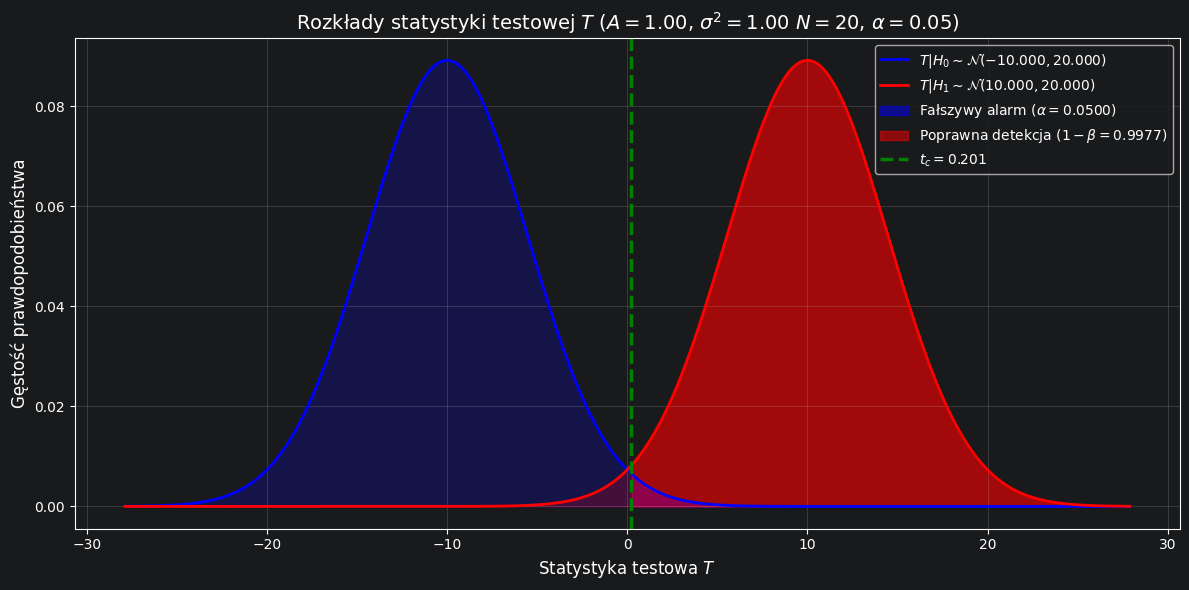

In [150]:
plot_distributions(
    signal_amplitude=1.0,
    signal_length=20,
    noise_variance=1.0,
    alpha=0.05,
    save_path="t-reasonable.png"
)

## Trudno rozdzielić przy $A < \sigma^2$

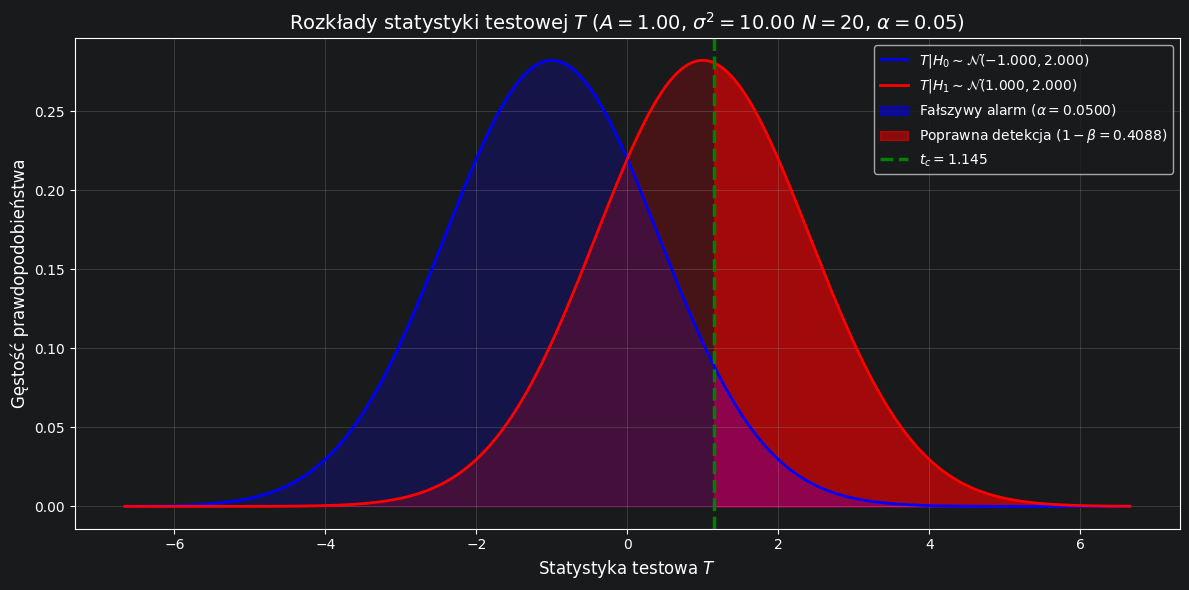

In [151]:
plot_distributions(
    signal_amplitude=1.0,
    signal_length=20,
    noise_variance=10.0,
    alpha=0.05,
    save_path="t-close.png"
)

## Da się rozdzielić zwiększając długość sygnału, nawet przy $A < \sigma^2$

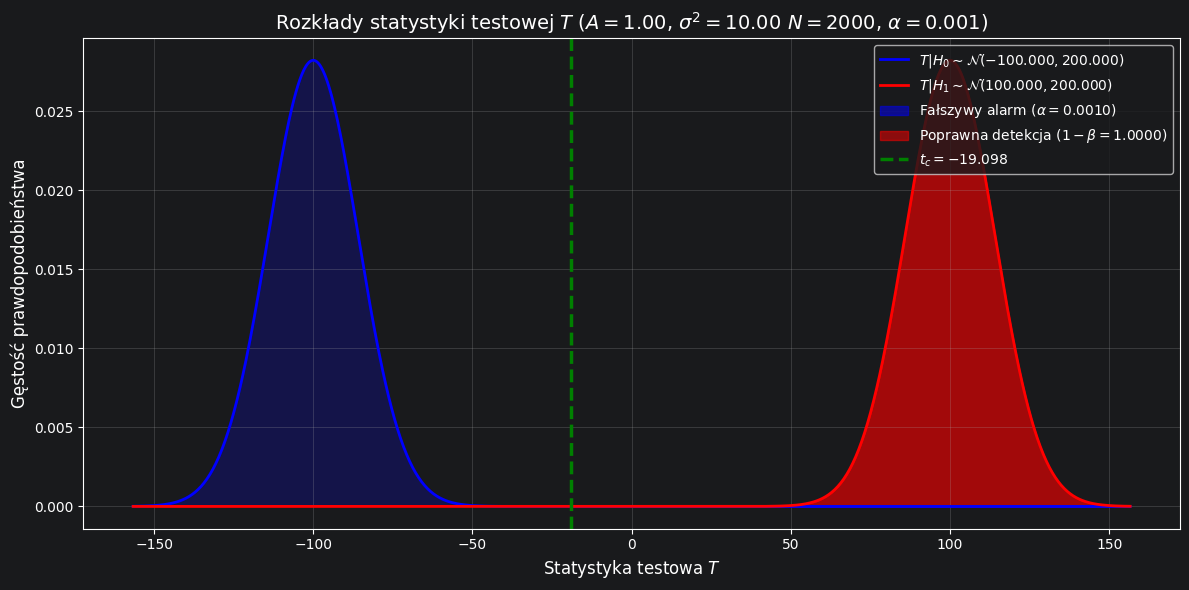

In [152]:
plot_distributions(
    signal_amplitude=1.0,
    signal_length=2000,
    noise_variance=10.0,
    alpha=0.001,
    save_path="t-far.png"
)